### Load Data

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
!pip install -q mlflow pyngrok

In [8]:
import mlflow
import subprocess
from pyngrok import ngrok, conf
import subprocess, time, requests
import getpass

In [9]:
!pkill -f "mlflow ui"
!pkill -f gunicorn
ngrok.kill()

In [10]:
proc = subprocess.Popen(
    ['mlflow', 'ui',
     '--backend-store-uri', 'sqlite:///mlflow.db',
     '--host', '127.0.0.1', '--port', '5000',
     '--allowed-hosts', '*',
     '--cors-allowed-origins', '*'],
    stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True
)

# wait for the server to actually respond
for i in range(30):
    if proc.poll() is not None:
        print("MLflow exited:\n", proc.stdout.read())
        break
    try:
        r = requests.get('http://127.0.0.1:5000', timeout=2)
        print("MLflow is up, status", r.status_code)
        break
    except Exception:
        time.sleep(2)
else:
    print("MLflow never responded")

ngrok.set_auth_token(getpass.getpass("ngrok authtoken: "))

public_url = ngrok.connect("127.0.0.1:5000").public_url
print(public_url)

MLflow is up, status 200
ngrok authtoken: ··········
https://elevate-mouse-crewless.ngrok-free.dev


In [11]:
# Set or create an experiment name
mlflow.set_experiment("Credit_Risk_Classification")

# Enable automatic logging for Scikit-learn and XGBoost
mlflow.autolog()

2026/10/05 04:03:18 INFO mlflow.tracking.fluent: Experiment with name 'Credit_Risk_Classification' does not exist. Creating a new experiment.
2026/10/05 04:03:18 INFO mlflow.tracking.fluent: Autologging successfully enabled for google.genai.
2026/10/05 04:03:18 INFO mlflow.tracking.fluent: Autologging successfully enabled for google.generativeai.
2026/10/05 04:03:36 INFO mlflow.tracking.fluent: Autologging successfully enabled for statsmodels.
2026/10/05 04:03:36 WARNING mlflow.spark: With Pyspark >= 3.2, PYSPARK_PIN_THREAD environment variable must be set to false for Spark datasource autologging to work.
2026/10/05 04:03:36 INFO mlflow.tracking.fluent: Autologging successfully enabled for pyspark.


In [12]:
df = pd.read_csv('credit_risk_dataset.csv')
df

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4
...,...,...,...,...,...,...,...,...,...,...,...,...
32576,57,53000,MORTGAGE,1.0,PERSONAL,C,5800,13.16,0,0.11,N,30
32577,54,120000,MORTGAGE,4.0,PERSONAL,A,17625,7.49,0,0.15,N,19
32578,65,76000,RENT,3.0,HOMEIMPROVEMENT,B,35000,10.99,1,0.46,N,28
32579,56,150000,MORTGAGE,5.0,PERSONAL,B,15000,11.48,0,0.10,N,26


### Basic Information about data

In [13]:
df.shape

(32581, 12)

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


### Null Values

In [15]:
df.isnull().sum()

,0
person_age,0
person_income,0
person_home_ownership,0
person_emp_length,895
loan_intent,0
loan_grade,0
loan_amnt,0
loan_int_rate,3116
loan_status,0
loan_percent_income,0


### Target Balance

In [16]:
df['loan_status'].unique()

array([1, 0])

In [17]:
df['loan_status'].value_counts()

,count
loan_status,
0,25473
1,7108


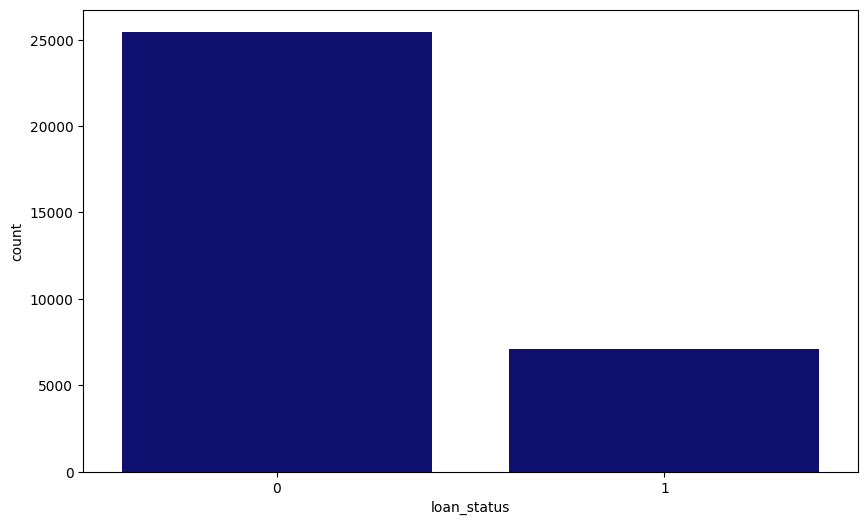

In [18]:
plt.figure(figsize=(10,6))
sns.countplot(x='loan_status',data=df, color='navy')
plt.show()

### Outlier Check

In [19]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [20]:
num_columns = df.select_dtypes(include='number')

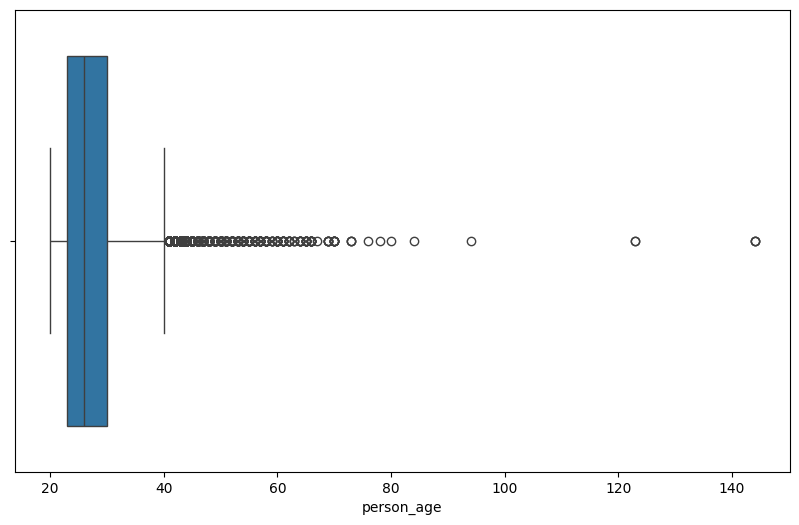

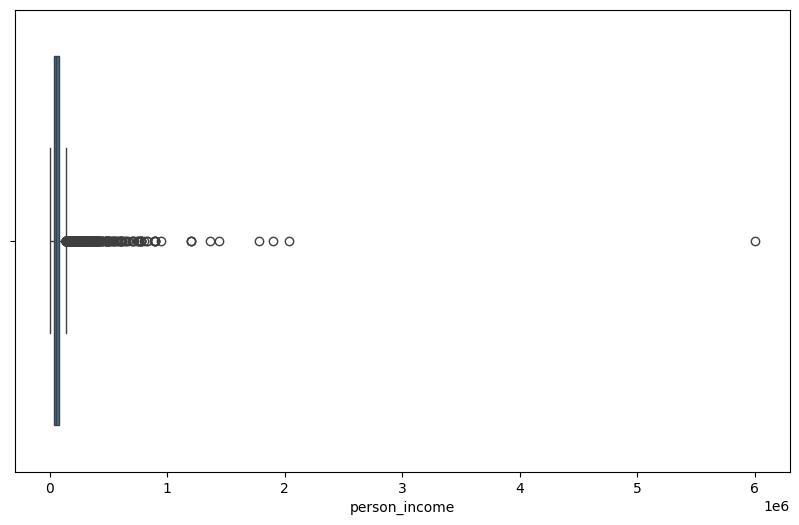

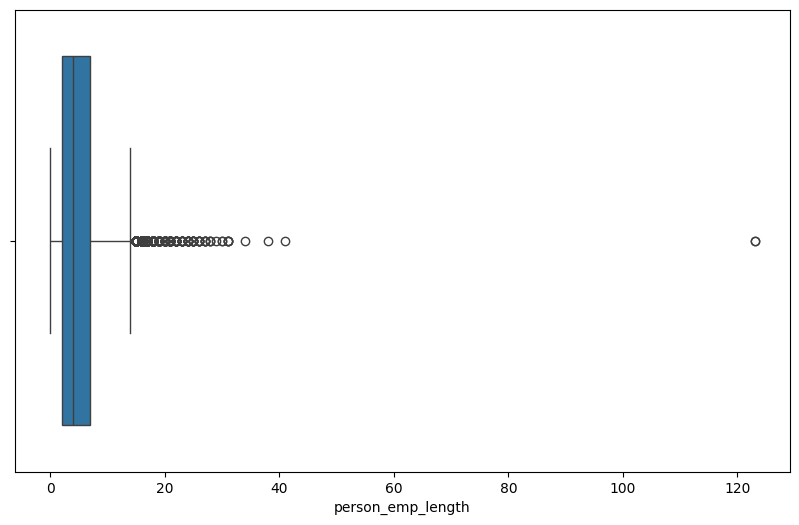

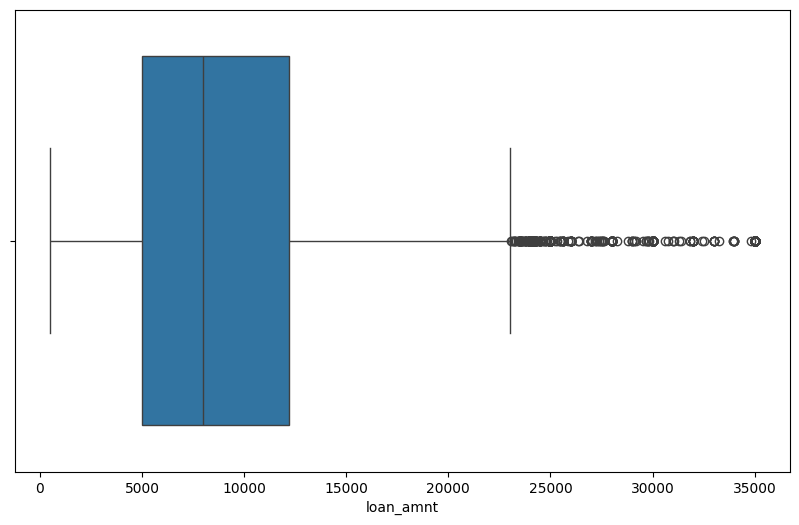

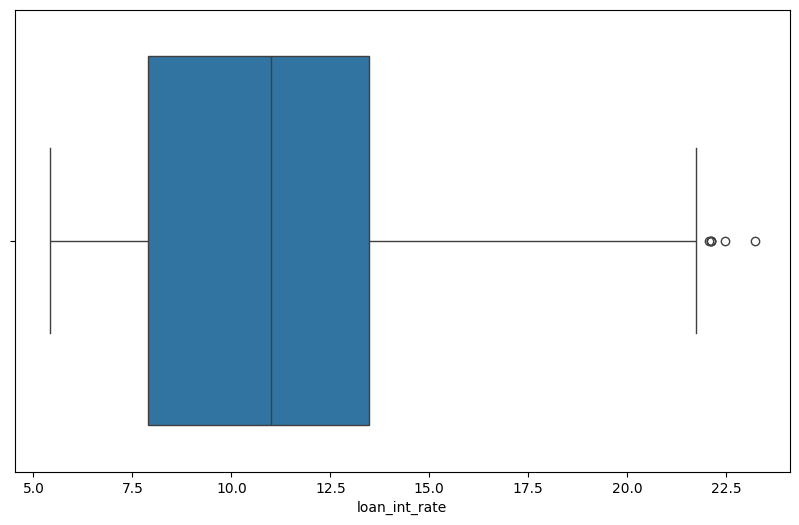

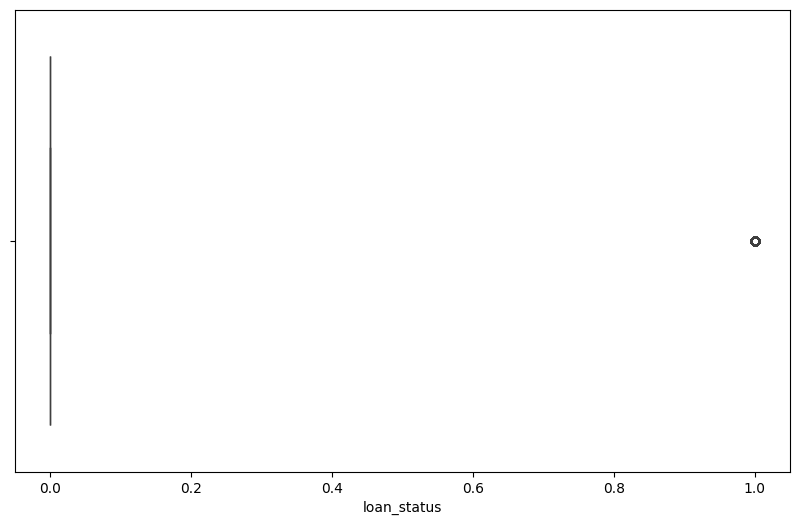

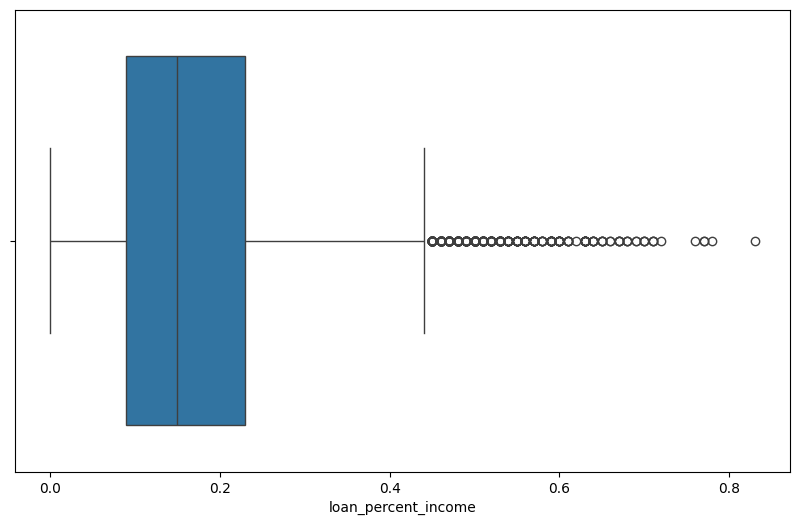

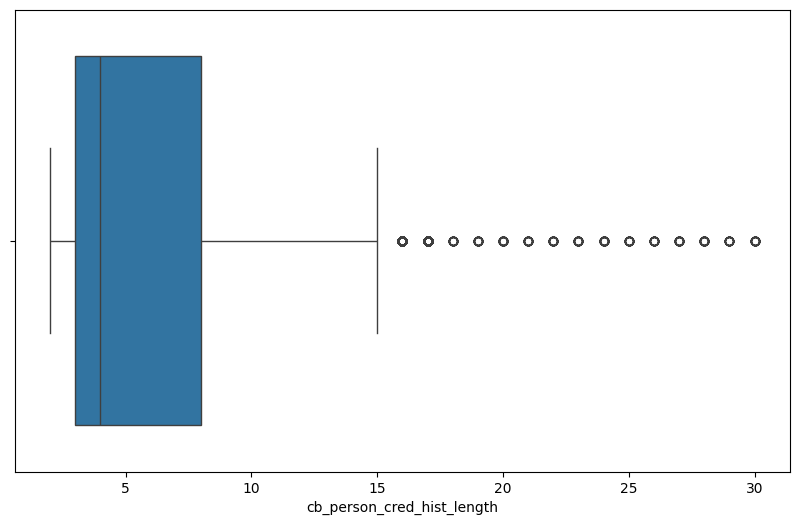

In [21]:
from scipy import stats

for i in list(num_columns.columns):
  plt.figure(figsize=(10,6))
  sns.boxplot(x=df[i])
  plt.show()

In [22]:
(df['person_age']>100).sum()

np.int64(5)

In [23]:
(df['person_emp_length'] > 60).sum()

np.int64(2)

### Correlation check

<Axes: >

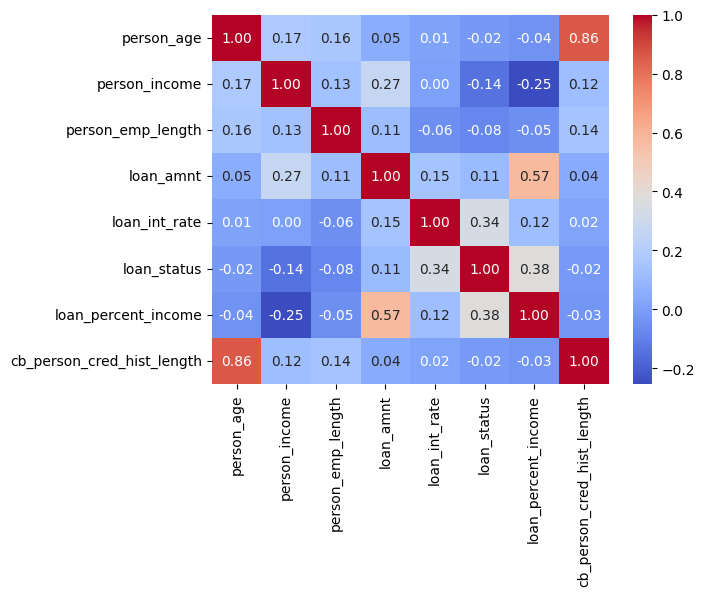

In [24]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')

### Cleaning data

In [25]:
df_copy = df.copy()

print(f'Original Rows: {df_copy.shape[0]}')

df_copy = df_copy.drop_duplicates()
print(f'Rows after removing duplicates: {df_copy.shape[0]}')


Original Rows: 32581
Rows after removing duplicates: 32416


In [26]:
df_copy = df_copy[df_copy['person_age']>=18]
df_copy = df_copy[df_copy['person_age']<=100]

In [27]:
df_copy['person_age'].describe()

,person_age
count,32411.000000
mean,27.730369
std,6.210448
min,20.000000
25%,23.000000
50%,26.000000
75%,30.000000
max,94.000000


In [28]:
df_copy = df_copy[df_copy['person_emp_length'] <= 60]


In [29]:
df_copy['person_emp_length'].describe()

,person_emp_length
count,31522.000000
mean,4.782850
std,4.037343
min,0.000000
25%,2.000000
50%,4.000000
75%,7.000000
max,41.000000


In [30]:
df_copy.columns

Index(['person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_default_on_file', 'cb_person_cred_hist_length'],
      dtype='object')

In [31]:
df_copy = df_copy[df_copy['loan_amnt'] > 0]

In [32]:
df_copy['loan_amnt'].describe()

,loan_amnt
count,31522.000000
mean,9663.771334
std,6334.787700
min,500.000000
25%,5000.000000
50%,8000.000000
75%,12500.000000
max,35000.000000


### Feature Target & Train Test Split

In [33]:
X = df_copy.drop('loan_status', axis=1)
y = df_copy['loan_status']

In [34]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42, stratify=y)

2026/10/05 04:03:51 INFO mlflow.tracking.fluent: Autologging successfully enabled for sklearn.


In [35]:
cat_columns = list(df_copy.select_dtypes(include='object').columns)
num_columns = list(df_copy.select_dtypes(include='number').columns)

if 'loan_status' in num_columns:
    num_columns.remove('loan_status')

### Handling Class Imbalance

In [36]:
y_train.value_counts()

,count
loan_status,
0,19772
1,5445


In [37]:
scale_weights = y_train[y_train==0].count()/y_train[y_train==1].count()
scale_weights

np.float64(3.6312213039485766)

In [38]:
num, deno = np.bincount(y_train)
scale_weights = num/deno
scale_weights

np.float64(3.6312213039485766)

### Data Preprocessing

In [39]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [40]:
preprocessor_lr = ColumnTransformer(
      transformers = [
          ('num', Pipeline(
              [
                  ('imputer', SimpleImputer(strategy='median')),
                  ('scaler', StandardScaler())
              ]), num_columns),

          ('cat',Pipeline(
              [
                  ('imputer', SimpleImputer(strategy='constant', fill_value='Missing')),
                  ('onehot', OneHotEncoder(handle_unknown='ignore'))
              ]), cat_columns)
            ])

In [41]:
preprocessor_xg = ColumnTransformer(
      transformers = [
          ('num', Pipeline(
              [
                  ('imputer', SimpleImputer(strategy='median'))
              ]), num_columns),

          ('cat',Pipeline(
              [
                  ('imputer', SimpleImputer(strategy='constant', fill_value='Missing')),
                  ('onehot', OneHotEncoder(handle_unknown='ignore'))
              ]), cat_columns)
            ])

### Stratified CV

In [42]:
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {'roc_auc':'roc_auc', 'accuracy':'accuracy', 'precision': 'precision', 'recall':'recall', 'f1': 'f1'}

In [43]:
from sklearn.linear_model import LogisticRegression

lr_cv_pipeline = Pipeline(
    [
        ('preprocessor', preprocessor_lr),
        ('classifier', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
    ]
)

In [44]:
lr_cv_pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['person_age',
                                                   'person_income',
                                                   'person_emp_length',
                                                   'loan_amnt', 'loan_int_rate',
                                                   'loan_percent_income',
                                                   'cb_person_cred_hist_length']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='Missing',
                                                                                 strategy='constant')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['person_home_ownership',
                                                   'loan_intent', 'loan_grade',
                                                   'cb_person_default_on_file'])])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])

In [45]:
from xgboost import XGBClassifier

xgb_classifier = Pipeline(
    [
        ('preprocessor', preprocessor_xg),
        ('classifier', XGBClassifier(
            n_estimators=300, max_depth=5, learning_rate=0.1, scale_pos_weight=scale_weights, random_state=42, n_jobs=-1)
        )
    ]
)

2026/10/05 04:03:52 INFO mlflow.tracking.fluent: Autologging successfully enabled for xgboost.


In [46]:
xgb_classifier

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['person_age',
                                                   'person_income',
                                                   'person_emp_length',
                                                   'loan_amnt', 'loan_int_rate',
                                                   'loan_percent_income',
                                                   'cb_person_cred_hist_length']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='Missing',
                                                                                 strategy='consta...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=5, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=300, n_jobs=-1,
                               num_parallel_tree=None, ...))])

In [47]:
from sklearn.model_selection import cross_validate

for cv_name, pipe in [("Logistic Regression", lr_cv_pipeline), ("XGBoost", xgb_classifier)]:
    cv_result = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    print(f'\n{cv_name}\n')
    print(f'ROC-AUC: {cv_result['test_roc_auc'].mean().round(2)}')
    print(f'Accuracy: {cv_result['test_accuracy'].mean().round(2)}')
    print(f'Precision: {cv_result['test_precision'].mean().round(2)}')
    print(f'Recall: {cv_result['test_recall'].mean().round(2)}')
    print(f'F1: {cv_result['test_f1'].mean().round(2)}')


Logistic Regression

ROC-AUC: 0.87
Accuracy: 0.81
Precision: 0.54
Recall: 0.78
F1: 0.64

XGBoost

ROC-AUC: 0.95
Accuracy: 0.92
Precision: 0.82
Recall: 0.8
F1: 0.81


In [48]:
cv_result

{'fit_time': array([2.64858437, 2.50789785, 1.75161457, 1.66253018, 0.89937615]),
 'score_time': array([0.34546781, 0.3101337 , 0.18790889, 0.18303227, 0.09482241]),
 'test_roc_auc': array([0.95037143, 0.93802547, 0.94787183, 0.94916053, 0.95004373]),
 'test_accuracy': array([0.92089611, 0.91732752, 0.91631965, 0.91929407, 0.91592306]),
 'test_precision': array([0.82485876, 0.836     , 0.81314554, 0.82048872, 0.80090498]),
 'test_recall': array([0.80440771, 0.76767677, 0.79522498, 0.80165289, 0.81267218]),
 'test_f1': array([0.81450488, 0.80038296, 0.80408542, 0.81096145, 0.80674567])}

In [49]:
cv_result.keys()

dict_keys(['fit_time', 'score_time', 'test_roc_auc', 'test_accuracy', 'test_precision', 'test_recall', 'test_f1'])

### Evaluation Helper Function

In [68]:
from sklearn.metrics import accuracy_score, precision_score, precision_recall_curve, recall_score, f1_score, confusion_matrix, classification_report

def evaluate_model_xgb(model_name, model, X_test, y_test, best_threshold):

  y_pred_prob = model.predict_proba(X_test)[:,1]
  y_pred = (y_pred_prob >= best_threshold).astype(int)

  accuracy_s = accuracy_score(y_test, y_pred)
  precision_s = precision_score(y_test, y_pred)
  recall_s = recall_score(y_test, y_pred)
  f1_s = f1_score(y_test, y_pred)

  cm = confusion_matrix(y_test, y_pred)
  class_report = classification_report(y_test, y_pred)

  mlflow.log_params(model.get_params())
  mlflow.log_metric("accuracy", accuracy_s)
  mlflow.log_metric("precision", precision_s)
  mlflow.log_metric("recall", recall_s)
  mlflow.log_metric("f1", f1_s)

  print(f'Best Threshold: {best_threshold:.2f}')
  print(f'Accuracy score: {accuracy_s:.2f}')
  print(f'Precision score: {precision_s:.2f}')
  print(f'Recall score: {recall_s:.2f}')
  print(f'F1 score: {f1_s:.2f}\n')
  print(f'{model_name} Classification Report: {class_report}')

  plt.figure(figsize=(6,4))
  sns.heatmap(cm, annot=True, fmt='.2f')
  plt.title('Confusion Matrix')
  plt.xlabel('Predicted values')
  plt.ylabel('Actual Values')
  plt.show()

  precisions, recalls, threshold = precision_recall_curve(y_test, y_pred_prob)
  plt.figure(figsize=(10,6))
  plt.xlabel('Recall')
  plt.ylabel('Precision')
  plt.plot(recalls, precisions)

def evaluate_model(model_name, model, X_test, y_test):
  y_pred = model.predict(X_test)
  y_pred_prob = model.predict_proba(X_test)[:,1]


  accuracy_s = accuracy_score(y_test, y_pred)
  precision_s = precision_score(y_test, y_pred)
  recall_s = recall_score(y_test, y_pred)
  f1_s = f1_score(y_test, y_pred)

  cm = confusion_matrix(y_test, y_pred)
  class_report = classification_report(y_test, y_pred)

  mlflow.log_params(model.get_params())
  mlflow.log_metric("accuracy", accuracy_s)
  mlflow.log_metric("precision", precision_s)
  mlflow.log_metric("recall", recall_s)
  mlflow.log_metric("f1", f1_s)

  print(f'Accuracy score: {accuracy_s:.2f}')
  print(f'Precision score: {precision_s:.2f}')
  print(f'Recall score: {recall_s:.2f}')
  print(f'F1 score: {f1_s:.2f}\n')
  print(f'{model_name} Classification Report: {class_report}')

  plt.figure(figsize=(6,4))
  sns.heatmap(cm, annot=True, fmt='.2f')
  plt.title('Confusion Matrix')
  plt.xlabel('Predicted values')
  plt.ylabel('Actual Values')
  plt.show()

  precisions, recalls, threshold = precision_recall_curve(y_test, y_pred_prob)
  plt.figure(figsize=(10,6))
  plt.xlabel('Recall')
  plt.ylabel('Precision')
  plt.plot(recalls, precisions)

### Baseline model - Logistic Regression

In [69]:
baseline_model = Pipeline(
    [
        ('preprocessor', preprocessor_lr),
        ('classifier', LogisticRegression(class_weight='balanced', random_state=42))
    ]
)

In [70]:
baseline_model

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['person_age',
                                                   'person_income',
                                                   'person_emp_length',
                                                   'loan_amnt', 'loan_int_rate',
                                                   'loan_percent_income',
                                                   'cb_person_cred_hist_length']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='Missing',
                                                                                 strategy='constant')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['person_home_ownership',
                                                   'loan_intent', 'loan_grade',
                                                   'cb_person_default_on_file'])])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', random_state=42))])

2026/10/05 04:24:06 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/usr/local/lib/python3.13/dist-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."
2026/10/05 04:24:07 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/usr/local/lib/python3.13/dist-packages/mlflow/types/utils

Accuracy score: 0.82
Precision score: 0.56
Recall score: 0.79
F1 score: 0.65

Baseline Logistic Model Classification Report:               precision    recall  f1-score   support

           0       0.93      0.83      0.88      4943
           1       0.56      0.79      0.65      1362

    accuracy                           0.82      6305
   macro avg       0.75      0.81      0.77      6305
weighted avg       0.85      0.82      0.83      6305



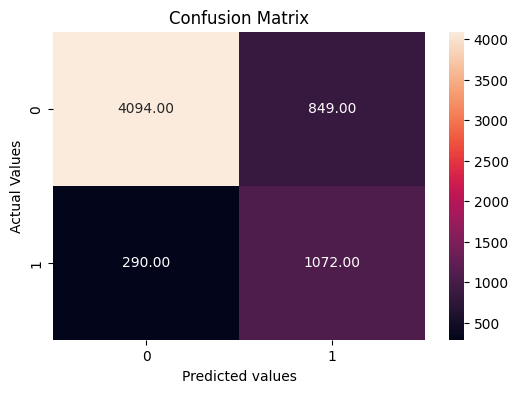

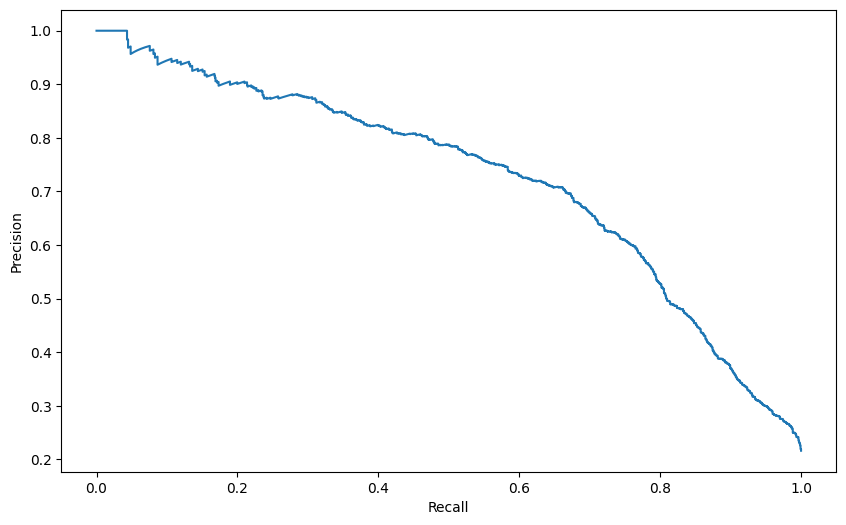

In [71]:
with mlflow.start_run(run_name="Logistic Regression BaseModel"):
  baseline_model.fit(X_train, y_train)
  evaluate_model('Baseline Logistic Model', baseline_model, X_test, y_test)

In [72]:
xg_model = Pipeline([
    ('preprocessor', preprocessor_xg),
    ('classifier', XGBClassifier(learning_rate=0.1,scale_pos_weight=scale_weights, random_state=42))
])

In [73]:
xg_model

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['person_age',
                                                   'person_income',
                                                   'person_emp_length',
                                                   'loan_amnt', 'loan_int_rate',
                                                   'loan_percent_income',
                                                   'cb_person_cred_hist_length']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='Missing',
                                                                                 strategy='consta...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None, ...))])

2026/10/05 04:24:17 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/usr/local/lib/python3.13/dist-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."
2026/10/05 04:24:18 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/usr/local/lib/python3.13/dist-packages/mlflow/types/utils

Accuracy score: 0.92
Precision score: 0.82
Recall score: 0.79
F1 score: 0.81

Baseline XGBoost Model Classification Report:               precision    recall  f1-score   support

           0       0.94      0.95      0.95      4943
           1       0.82      0.79      0.81      1362

    accuracy                           0.92      6305
   macro avg       0.88      0.87      0.88      6305
weighted avg       0.92      0.92      0.92      6305



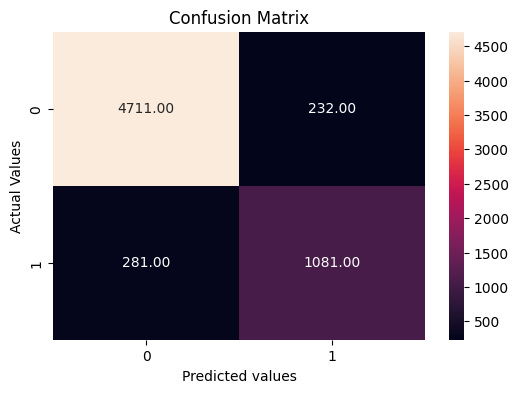

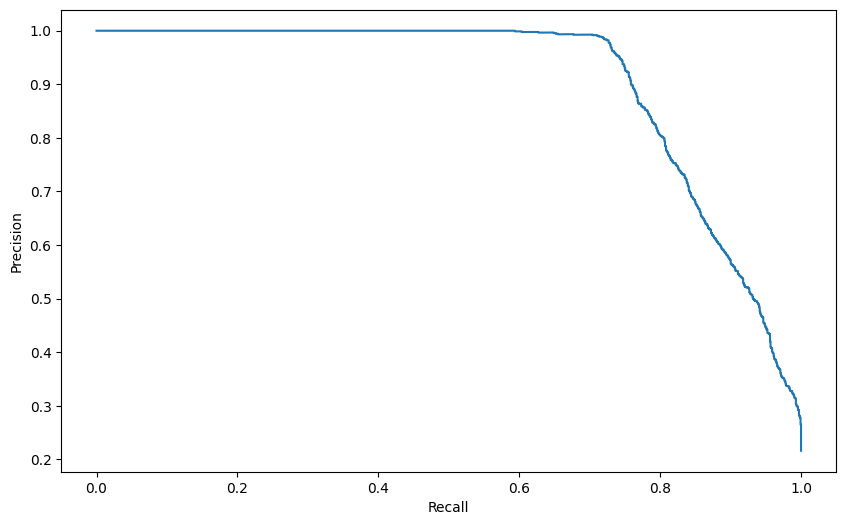

In [74]:
with mlflow.start_run(run_name="XGBoost BaseModel"):
  xg_model.fit(X_train, y_train)
  evaluate_model('Baseline XGBoost Model', xg_model, X_test, y_test)

In [75]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint

param_grid = {
    'classifier__n_estimators': randint(150,600),
    'classifier__max_depth': randint(3,9),
    'classifier__learning_rate': uniform(0.01, 0.5),
    'classifier__subsample': uniform(0.6,0.4), # row_sampling
    'classifier__colsample_bytree': uniform(0.6,0.4), # column_sampling
    'classifier__min_child_weight': randint(1,10),
    'classifier__gamma': uniform(0, 5)
}

In [76]:
random_search = RandomizedSearchCV(
    xg_model,
    param_grid,
    n_iter=150,
    cv=cv,
    scoring='average_precision',
    n_jobs=-1,
    verbose=1
)

2026/10/05 04:43:12 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/usr/local/lib/python3.13/dist-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."


Fitting 5 folds for each of 150 candidates, totalling 750 fits


2026/10/05 04:56:30 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/usr/local/lib/python3.13/dist-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."
2026/10/05 04:56:30 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely

Accuracy score: 0.92
Precision score: 0.81
Recall score: 0.81
F1 score: 0.81

Tuned XGBoost Model Classification Report:               precision    recall  f1-score   support

           0       0.95      0.95      0.95      4943
           1       0.81      0.81      0.81      1362

    accuracy                           0.92      6305
   macro avg       0.88      0.88      0.88      6305
weighted avg       0.92      0.92      0.92      6305



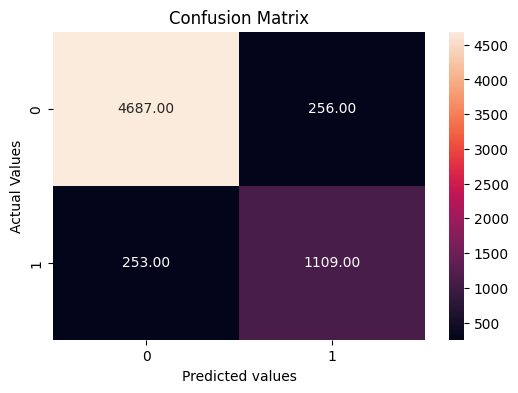

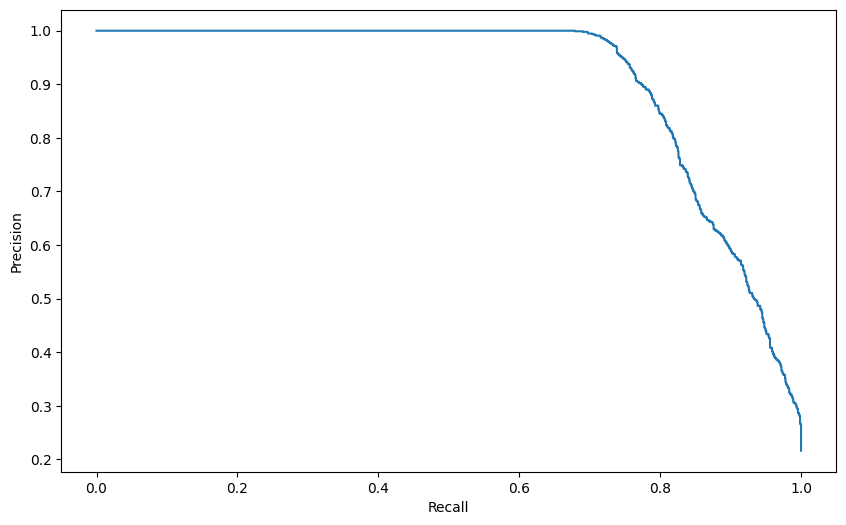

In [78]:
with mlflow.start_run(run_name="XGBoost_with_RandomizedSearch"):
  random_search.fit(X_train, y_train)

  best_xgb_model = random_search.best_estimator_

  best_xgb_params = random_search.best_params_

  best_xgb_score = random_search.best_score_

with mlflow.start_run(run_name="Tuned XGBoost Evaluation"):

    mlflow.log_params(best_xgb_params)
    mlflow.log_metric("best_cv_score", best_xgb_score)
    evaluate_model('Tuned XGBoost Model', best_xgb_model, X_test, y_test)

### Optimising the threshold

In [79]:
prob = xg_model.predict_proba(X_test)[:,1]

2026/10/05 05:08:48 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/usr/local/lib/python3.13/dist-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."


In [80]:
precisions, recalls, thresholds = precision_recall_curve(y_test, prob)

In [81]:
f1 = 2 * (precisions * recalls) / (precisions + recalls)
f1

array([0.3552889 , 0.35533525, 0.3553816 , ..., 0.00293255, 0.00146735,
       0.        ])

In [82]:
best = np.argmax(f1[:-1])
best

np.int64(5286)

In [83]:
best_threshold = thresholds[best]
best_threshold

np.float32(0.7559226)

2026/10/05 05:12:15 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/usr/local/lib/python3.13/dist-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."


Best Threshold: 0.76
Accuracy score: 0.94
Precision score: 0.98
Recall score: 0.73
F1 score: 0.84

XGBoost_with_Optimised_Threshold Classification Report:               precision    recall  f1-score   support

           0       0.93      1.00      0.96      4943
           1       0.98      0.73      0.84      1362

    accuracy                           0.94      6305
   macro avg       0.96      0.86      0.90      6305
weighted avg       0.94      0.94      0.93      6305



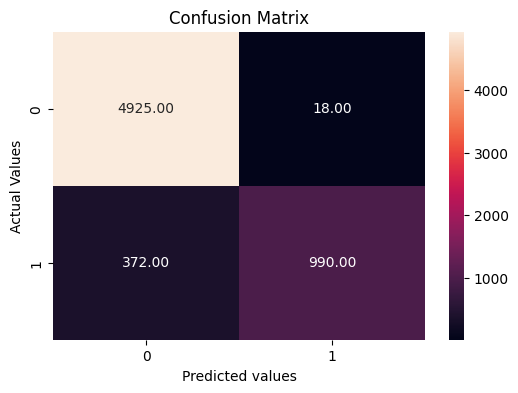

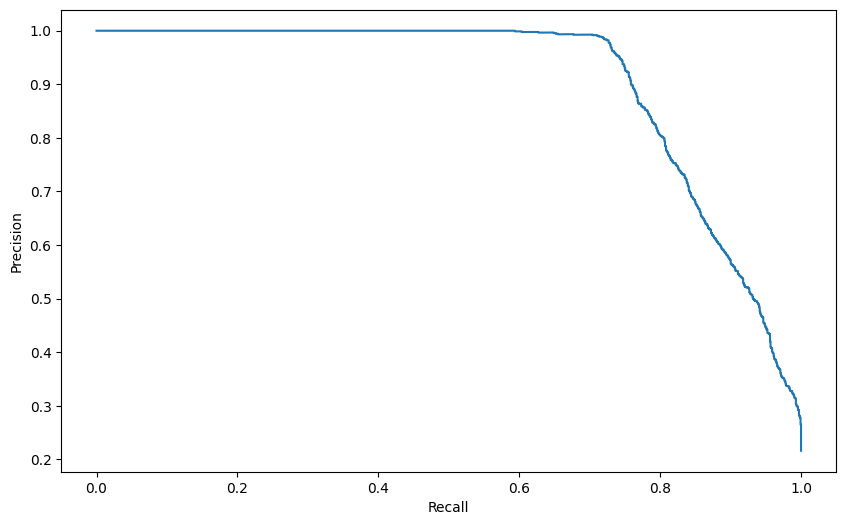

In [86]:
evaluate_model_xgb('XGBoost_with_Optimised_Threshold', xg_model, X_test, y_test, best_threshold)

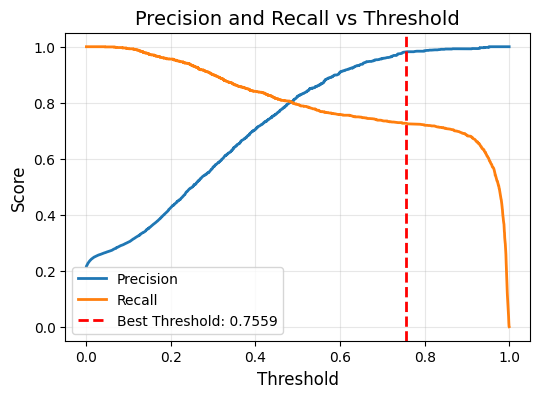

In [85]:
plt.figure(figsize=(6, 4))
plt.plot(thresholds, precisions[:-1], label='Precision', linewidth=2)
plt.plot(thresholds, recalls[:-1], label='Recall', linewidth=2)
plt.xlabel('Threshold', fontsize=12)
plt.ylabel('Score', fontsize=12)

plt.axvline(x=best_threshold, color='red', linestyle='--', linewidth=2, label=f'Best Threshold: {best_threshold:.4f}')

plt.title('Precision and Recall vs Threshold', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Probability Calibration

In [91]:
from sklearn.calibration import CalibratedClassifierCV, calibration_curve

calibrated_model = CalibratedClassifierCV(
    xg_model,
    method='sigmoid',
    cv=5
)

2026/10/05 05:26:51 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/usr/local/lib/python3.13/dist-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."
2026/10/05 05:27:03 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/usr/local/lib/python3.13/dist-packages/mlflow/types/utils

Best Threshold: 0.76
Accuracy score: 0.94
Precision score: 0.98
Recall score: 0.72
F1 score: 0.83

Calibrated XGB Eval Classification Report:               precision    recall  f1-score   support

           0       0.93      1.00      0.96      4943
           1       0.98      0.72      0.83      1362

    accuracy                           0.94      6305
   macro avg       0.96      0.86      0.90      6305
weighted avg       0.94      0.94      0.93      6305



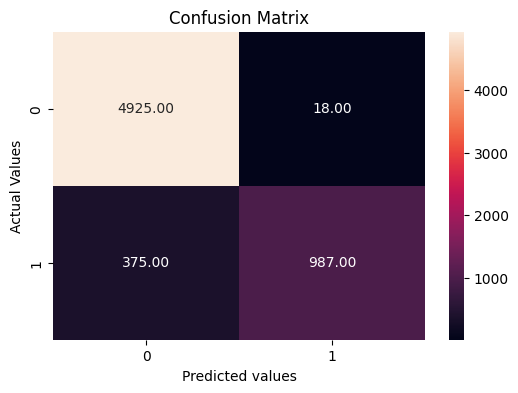

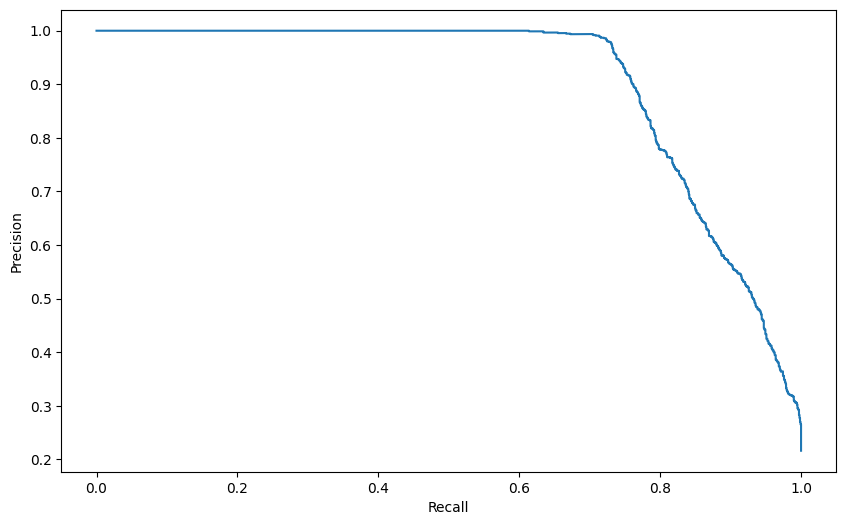

In [99]:
with mlflow.start_run(run_name='Calibrated XGBoost Model'):
  calibrated_model.fit(X_train, y_train)
  evaluate_model_xgb('Calibrated XGB Eval', calibrated_model, X_test, y_test, best_threshold)

In [135]:
calibrated = calibrated_model.predict_proba(X_test)[:,1]
calibrated

2026/10/05 05:48:54 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/usr/local/lib/python3.13/dist-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."


array([0.75711989, 0.04616006, 0.94900388, ..., 0.17461011, 0.01793189,
       0.01380934])

In [136]:
uncalibrated = xg_model.predict_proba(X_test)[:,1]
uncalibrated

2026/10/05 05:49:14 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/usr/local/lib/python3.13/dist-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."


array([0.8254656 , 0.25111562, 0.9782833 , ..., 0.48520026, 0.07587515,
       0.05467961], dtype=float32)

In [137]:
uncalibrated_lr = baseline_model.predict_proba(X_test)[:,1]
uncalibrated_lr

2026/10/05 05:49:19 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/usr/local/lib/python3.13/dist-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."


array([0.98318761, 0.63445052, 0.67825943, ..., 0.20636966, 0.08144692,
       0.08720381])

In [138]:
actual_cal, predicted_cal = calibration_curve(y_test, calibrated, n_bins=10)

In [139]:
actual_uncal, predicted_uncal = calibration_curve(y_test, uncalibrated, n_bins=10)

In [140]:
actual_uncal_lr, predicted_uncal_lr = calibration_curve(y_test, uncalibrated_lr, n_bins=10)

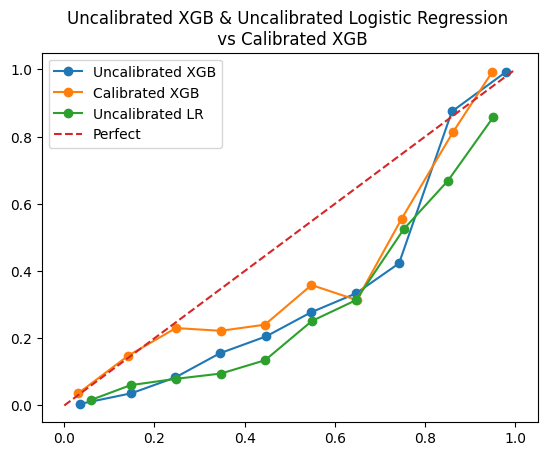

In [141]:
plt.plot(predicted_uncal, actual_uncal, 'o-', label='Uncalibrated XGB')
plt.plot(predicted_cal, actual_cal, 'o-', label='Calibrated XGB')
plt.plot(predicted_uncal_lr, actual_uncal_lr, 'o-', label='Uncalibrated LR')
plt.plot([0,1],[0,1], '--', label='Perfect')
plt.title('Uncalibrated XGB & Uncalibrated Logistic Regression \n vs Calibrated XGB')
plt.legend()
plt.show()

### SHAP Interpretation

In [150]:
!pip install shap

In [151]:
import shap

In [152]:
xgb_classifier = xg_model.named_steps['classifier']

In [153]:
X_test_transformed = xg_model.named_steps['preprocessor'].transform(X_test)

In [154]:
feature_names = xg_model.named_steps['preprocessor'].get_feature_names_out()

In [155]:
X_test_df = pd.DataFrame(X_test_transformed, columns=feature_names)
X_test_df

,num__person_age,num__person_income,num__person_emp_length,num__loan_amnt,num__loan_int_rate,num__loan_percent_income,num__cb_person_cred_hist_length,cat__person_home_ownership_MORTGAGE,cat__person_home_ownership_OTHER,cat__person_home_ownership_OWN,...,cat__loan_intent_VENTURE,cat__loan_grade_A,cat__loan_grade_B,cat__loan_grade_C,cat__loan_grade_D,cat__loan_grade_E,cat__loan_grade_F,cat__loan_grade_G,cat__cb_person_default_on_file_N,cat__cb_person_default_on_file_Y
0,24.0,30000.0,1.0,15000.0,15.68,0.50,3.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
1,23.0,60000.0,6.0,25600.0,10.99,0.43,4.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
2,29.0,18000.0,2.0,3600.0,15.27,0.20,6.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,32.0,130000.0,7.0,13000.0,12.69,0.10,8.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,23.0,45288.0,7.0,20500.0,9.25,0.45,2.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6300,21.0,75000.0,5.0,20000.0,13.11,0.27,2.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
6301,29.0,265000.0,2.0,25000.0,11.26,0.09,10.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
6302,25.0,48996.0,8.0,5000.0,9.88,0.10,2.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
6303,27.0,115000.0,11.0,8000.0,7.51,0.07,7.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [157]:
explainer = shap.TreeExplainer(xgb_classifier)

In [158]:
shap_values = explainer.shap_values(X_test_df)
shap_values

array([[-1.7525564e-01, -1.0555401e-01,  1.2984274e-01, ...,
        -7.3516299e-03, -3.8879909e-02,  0.0000000e+00],
       [ 4.7165085e-02, -8.7262326e-01, -9.4737314e-02, ...,
        -9.2151780e-03, -7.5508673e-03,  0.0000000e+00],
       [ 7.8027323e-02,  3.5025654e+00,  1.2711690e-01, ...,
        -7.3584518e-03,  7.7456667e-04,  0.0000000e+00],
       ...,
       [-8.6244913e-03,  5.8208084e-01,  7.2391242e-02, ...,
        -9.2837382e-03, -1.1459960e-02,  0.0000000e+00],
       [ 2.0838849e-02, -1.0313793e+00,  4.3692421e-02, ...,
        -9.2305308e-03, -1.1398584e-02,  0.0000000e+00],
       [-1.3665082e-01, -5.0866711e-01,  2.6854105e-02, ...,
        -8.8342456e-03, -1.0388625e-02,  0.0000000e+00]], dtype=float32)

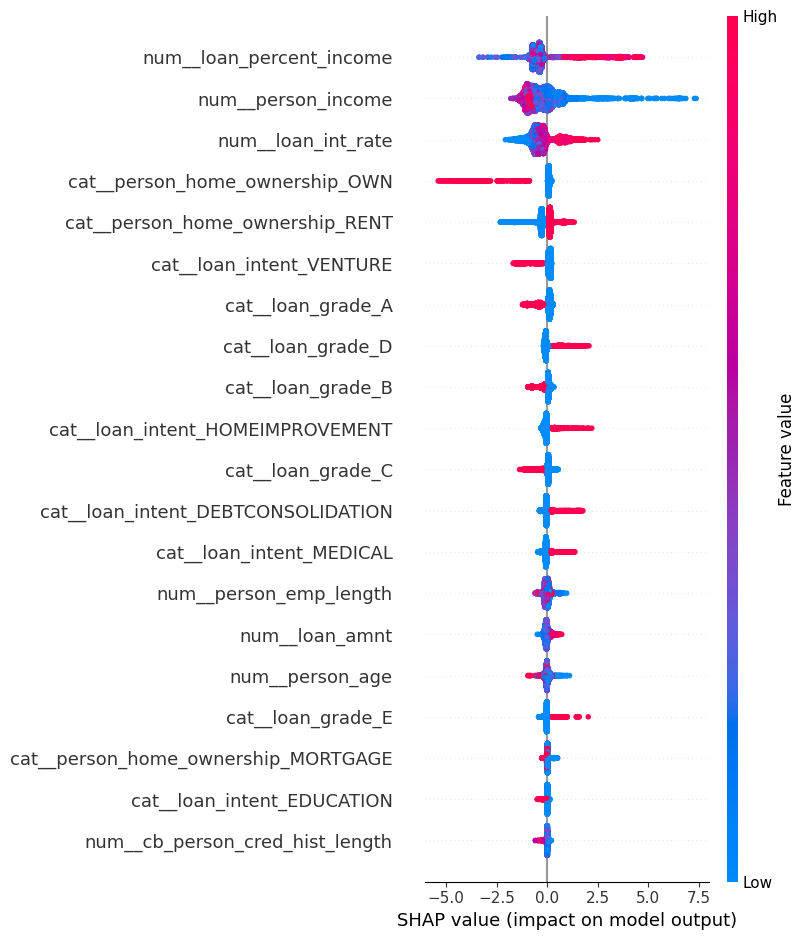

In [159]:
shap.summary_plot(shap_values, X_test_df)

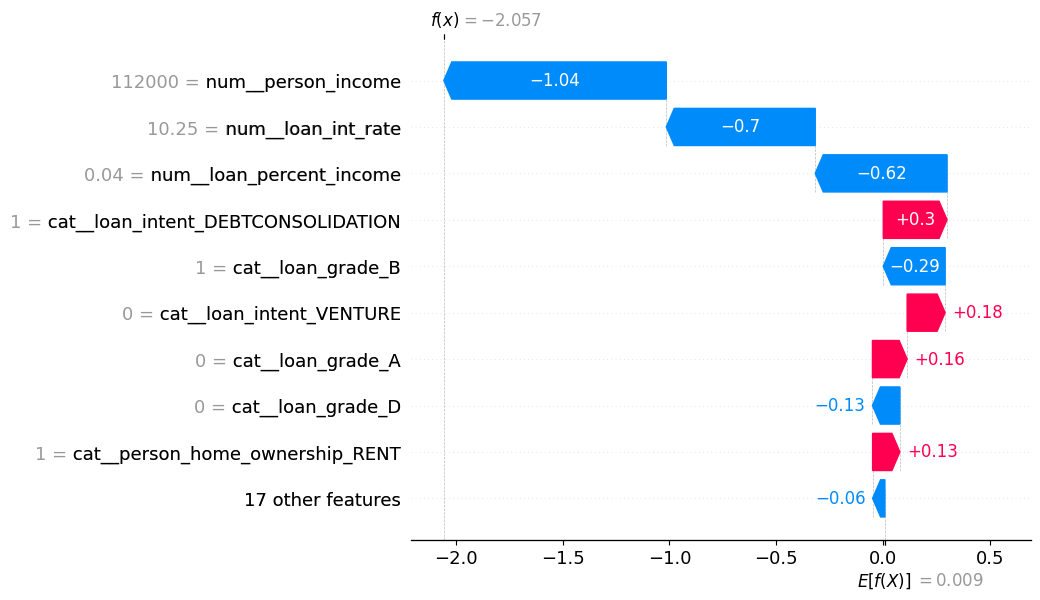

In [164]:
row_index = 10

shap.plots.waterfall(
    shap.Explanation(
        values = shap_values[row_index],
        base_values = explainer.expected_value,
        data = X_test_df.iloc[row_index],
        feature_names = feature_names

    )
 )


In [181]:
y_pred = random_search.predict(X_test)
y_pred

2026/10/05 07:31:06 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/usr/local/lib/python3.13/dist-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."


array([1, 0, 1, ..., 1, 0, 0])

2026/10/05 07:32:12 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/usr/local/lib/python3.13/dist-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."


Best Threshold: 0.76
Accuracy score: 0.94
Precision score: 0.97
Recall score: 0.74
F1 score: 0.84

XGBoost Tuned Model Classification Report:               precision    recall  f1-score   support

           0       0.93      0.99      0.96      4943
           1       0.97      0.74      0.84      1362

    accuracy                           0.94      6305
   macro avg       0.95      0.87      0.90      6305
weighted avg       0.94      0.94      0.93      6305



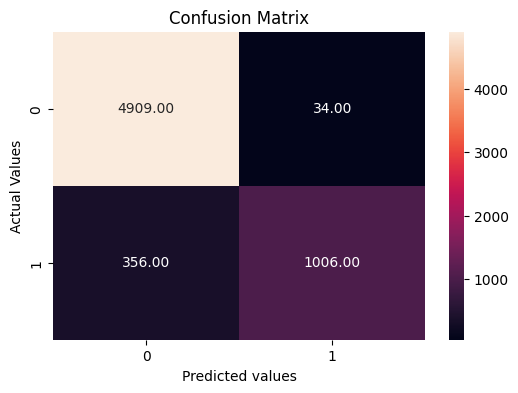

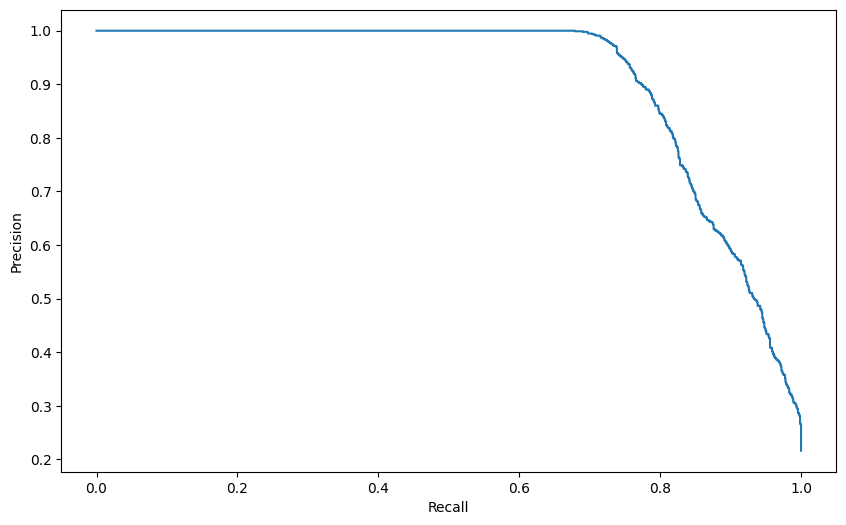

In [185]:
evaluate_model_xgb('XGBoost Tuned Model', random_search, X_test, y_test, best_threshold)

In [182]:
result_df = X_test.copy()
result_df['actual'] = y_test
result_df['predicted'] = y_pred

In [183]:
false_positive = result_df[(result_df['actual']==0) & (result_df['predicted']==1)]
false_negative = result_df[(result_df['actual']==1) & (result_df['predicted']==0)]

In [184]:
print(f'FP: {len(false_positive)}')
print(f'FN: {len(false_negative)}')

FP: 256
FN: 253


2026/10/05 07:43:11 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/usr/local/lib/python3.13/dist-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."
2026/10/05 07:43:27 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/usr/local/lib/python3.13/dist-packages/mlflow/types/utils

Best Threshold: 0.76
Accuracy score: 0.94
Precision score: 0.98
Recall score: 0.73
F1 score: 0.84

Calibrated RS XGBModel Classification Report:               precision    recall  f1-score   support

           0       0.93      1.00      0.96      4943
           1       0.98      0.73      0.84      1362

    accuracy                           0.94      6305
   macro avg       0.95      0.86      0.90      6305
weighted avg       0.94      0.94      0.94      6305



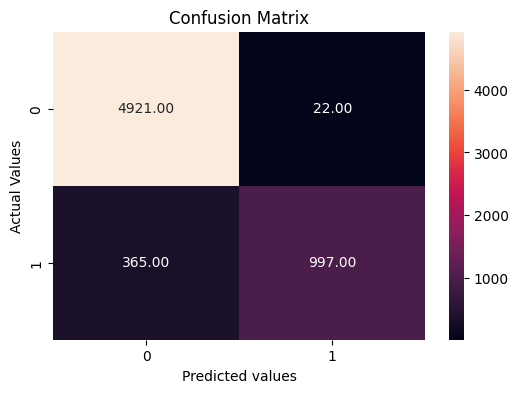

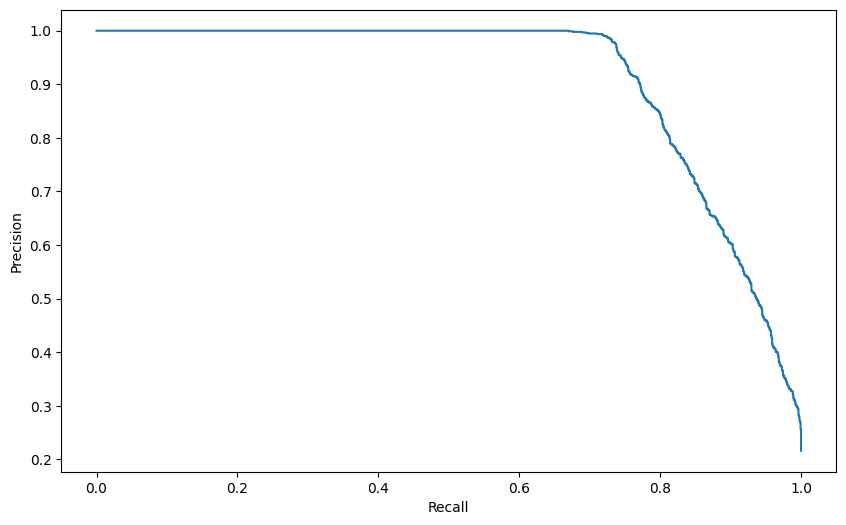

In [194]:
from sklearn.calibration import CalibratedClassifierCV, calibration_curve

best_model = random_search.best_estimator_

calibrated_model_rs = CalibratedClassifierCV(
    best_model,
    method='sigmoid',
    cv=5
)

mlflow.end_run()  # close any run left open by a previous cell

with mlflow.start_run(run_name="calibrated_rs_xgb"):
       calibrated_model_rs.fit(X_train, y_train)
       evaluate_model_xgb('Calibrated RS XGBModel', calibrated_model_rs, X_test, y_test, best_threshold)

In [195]:
import joblib

joblib.dump(calibrated_model, 'credit_risk_model.pkl')

['credit_risk_model.pkl']

In [196]:
joblib.dump(best_threshold,'best_threshold.pkl')

['best_threshold.pkl']